In [1]:
#  LASSO implemented in model to predict ridership

In [2]:
## Packages

In [3]:
# Data handling
import pandas as pd
import geopandas as gpd
import numpy as np

# Geopandas Dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap
import plotly.express as px


# Model requirements
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


# Model validation
from sklearn.model_selection import train_test_split, cross_val_score

In [4]:
## Read the Clean datsets

In [5]:
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

In [6]:
# show datset
display(origin.head())

,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


In [7]:
## Train test split

In [8]:
#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
X = pd.get_dummies(X, drop_first=True) #one_hot encoding here
Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)

In [9]:
from sklearn.preprocessing import OneHotEncoder

#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
#one hot encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop = 'first')
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([X, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
X = df_encoded

Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)


display(X)

,month,hour_of_day,origin_latitude,origin_longitude,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,...,"origin_station_complex_name_West Farms Sq-E Tremont Av (2,5)",origin_station_complex_name_Westchester Sq-E Tremont Av (6),origin_station_complex_name_Whitlock Av (6),origin_station_complex_name_Wilson Av (L),"origin_station_complex_name_Winthrop St (2,5)","origin_station_complex_name_Woodhaven Blvd (J,Z)","origin_station_complex_name_Woodhaven Blvd (M,R)",origin_station_complex_name_Woodlawn (4),origin_station_complex_name_York St (F),origin_station_complex_name_Zerega Av (6)
0,1,0,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,3,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,4,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852928,12,19,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852929,12,20,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852930,12,21,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852931,12,22,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
#train test split happening
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4)

In [11]:
## End of Atticus's code

In [12]:
## LASSO Model

In [11]:
# standardize
from sklearn.preprocessing import StandardScaler

scalerX = StandardScaler().fit(X_train) 
X_train_scaled = scalerX.transform(X_train)
X_test_scaled = scalerX.transform(X_test)



In [ ]:
# 5-fold cross-validation to choose lambda
#from sklearn.linear_model import LassoCV

#lasso_cv_model = LassoCV(
#    alphas=np.arange(0.01, 1, 0.1), cv=5, max_iter=100000
#)

# fit model on train set
#lasso_best = lasso_cv_model.fit(X_train_scaled, y_train)

In [ ]:
# chosen value of lambda
#lasso_best.alpha_

In [55]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression


# Starting the lasso regression engine
lasso_10 = Lasso(alpha = 10)
lasso_10.fit(X_train, y_train)
lasso_coefs10 = lasso_10.coef_

linear_model = LinearRegression().fit(X_train, y_train)
linear_coefs = linear_model.coef_

# Most of the differences are 0's
pd.DataFrame({
    'term' : X_train.columns,
    'OLS'  : linear_coefs,
    'Lasso': lasso_coefs10,
    'estimate_diff': (lasso_coefs10 - linear_coefs)#.round().astype(int)
})#.query('estimate_diff != 0')

,term,OLS,Lasso,estimate_diff
0,month,3.319668,2.426274,-0.893393
1,hour_of_day,13.491434,13.266051,-0.225384
2,origin_latitude,714.939817,0.000000,-714.939817
3,origin_longitude,-3400.145607,-0.000000,3400.145607
4,day_of_week_Monday,-12.521707,-0.000000,12.521707
...,...,...,...,...
428,"origin_station_complex_name_Woodhaven Blvd (J,Z)",-178.970930,-0.000000,178.970930
429,"origin_station_complex_name_Woodhaven Blvd (M,R)",152.531642,0.000000,-152.531642
430,origin_station_complex_name_Woodlawn (4),-318.429534,-0.000000,318.429534
431,origin_station_complex_name_York St (F),-308.023374,0.000000,308.023374


In [56]:
# how many coeffs aren't zero
sum(np.abs(lasso_10.coef_) > 0)

np.int64(5)

In [57]:
# Getting the coefficients of the model for the best choice of lambda
vars_matter_df = pd.DataFrame({
    'feature' : X.columns,
    'estimate': lasso_10.coef_.round(2)
}).query('estimate != 0')
display(vars_matter_df)



,feature,estimate
0,month,2.43
1,hour_of_day,13.27
5,day_of_week_Saturday,-28.85
6,day_of_week_Sunday,-75.07
408,"origin_station_complex_name_Times Sq-42 St (N,...",448.70


,feature,estimate
0,month,3.33
1,hour_of_day,13.49
2,origin_latitude,320.82
3,origin_longitude,-1119.91
4,day_of_week_Monday,-12.57
...,...,...
398,origin_station_complex_name_South Ferry (1)/Wh...,481.38
405,origin_station_complex_name_Sutphin Blvd-Arche...,715.02
408,"origin_station_complex_name_Times Sq-42 St (N,...",4843.87
417,"origin_station_complex_name_W 4 St-Wash Sq (A,...",980.03


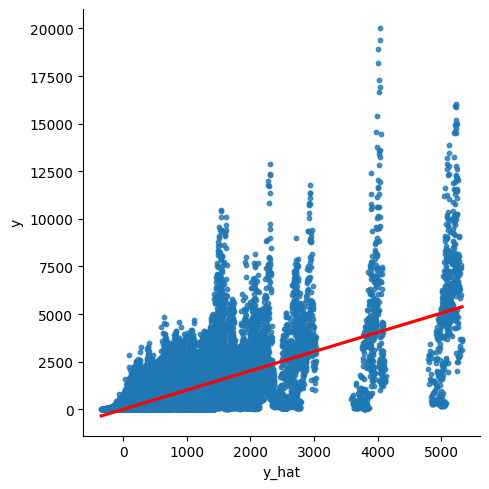

In [58]:
# fit mlr model with significant predictors


best_mlr = (
    LinearRegression()
    .fit(
        X = X_train[vars_matter['feature']],
        y = y_train
    )
)

display(pd.DataFrame({
    'feature' : vars_matter['feature'],
    'estimate': best_mlr.coef_.round(2)
}))

# Creating an R-squared plot:
sns.lmplot(
    data = pd.DataFrame({
        'y': y_test,
        'y_hat': best_mlr.predict(X = X_test[vars_matter['feature']])
    }),
    x = 'y_hat',
    y = 'y',
    line_kws = {'color': 'red'},
    scatter_kws = {'s' : 10}
)

plt.show()

In [59]:
origin[origin['origin_station_complex_name'] != 'Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)']['sum_estimated_average_ridership'].mean()

np.float64(310.7676970984243)

In [60]:
origin[origin['origin_station_complex_name'] != 'Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)']['sum_estimated_average_ridership'].mean()

np.float64(310.7676970984243)

In [61]:
best_mlr.score(X_test[vars_matter['feature']], y_test)

0.49154639113820764

## Take 2

In [46]:
# 5-fold cross-validation to choose lambda
from sklearn.linear_model import LassoCV

lasso_cv_model = LassoCV(
   alphas=np.arange(0.01, 10, 0.2), cv=5, max_iter=100000
)

# fit model on train set
lasso_best = lasso_cv_model.fit(X_train_scaled, y_train)

In [47]:
# chosen value of lambda
lasso_best.alpha_

np.float64(0.01)

In [48]:
# Getting the coefficients of the model for the best choice of lambda
vars_matter_df_2 = pd.DataFrame({
    'feature' : X.columns,
    'estimate': lasso_best.coef_.round(2)
}).query('estimate != 0')
display(vars_matter_df_2)

,feature,estimate
0,month,11.45
1,hour_of_day,93.35
3,origin_longitude,-263.75
4,day_of_week_Monday,-4.38
5,day_of_week_Saturday,-38.55
...,...,...
427,"origin_station_complex_name_Winthrop St (2,5)",-16.21
429,"origin_station_complex_name_Woodhaven Blvd (M,R)",16.43
430,origin_station_complex_name_Woodlawn (4),-1.75
431,origin_station_complex_name_York St (F),-14.46


,feature,estimate
0,month,3.32
1,hour_of_day,13.49
3,origin_longitude,-4979.74
4,day_of_week_Monday,-12.52
5,day_of_week_Saturday,-110.28
...,...,...
427,"origin_station_complex_name_Winthrop St (2,5)",-363.72
429,"origin_station_complex_name_Woodhaven Blvd (M,R)",331.62
430,origin_station_complex_name_Woodlawn (4),-45.05
431,origin_station_complex_name_York St (F),-337.25


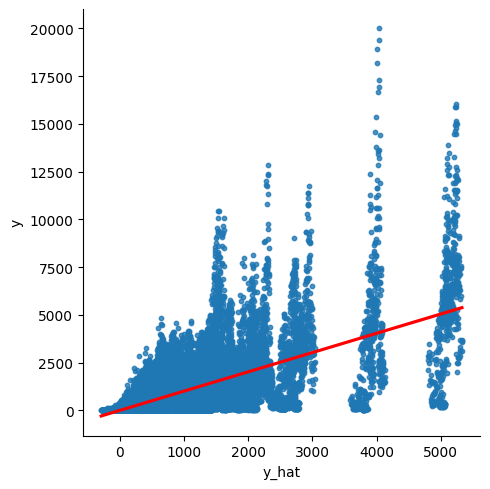

In [50]:
# fit mlr model with significant predictors


best_mlr_2 = (
    LinearRegression()
    .fit(
        X = X_train[vars_matter_df_2['feature']],
        y = y_train
    )
)

display(pd.DataFrame({
    'feature' : vars_matter_df_2['feature'],
    'estimate': best_mlr_2.coef_.round(2)
}))

# Creating an R-squared plot:
sns.lmplot(
    data = pd.DataFrame({
        'y': y_test,
        'y_hat': best_mlr_2.predict(X = X_test[vars_matter_df_2['feature']])
    }),
    x = 'y_hat',
    y = 'y',
    line_kws = {'color': 'red'},
    scatter_kws = {'s' : 10}
)

plt.show()

In [53]:
best_mlr_2.score(X_test[vars_matter_df_2['feature']], y_test)

0.5084111434241331

# example

#example
example 2

example 3
- example 4
- example 5

1) example 6
1) example 7 